<a href="https://colab.research.google.com/github/nguyenasd132/AI2026/blob/main/SVR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SVR

1.Định nghĩa SVR

Support Vector Regression (SVR) là một thuật toán học máy có giám sát, được sử dụng để giải quyết các bài toán hồi quy, dùng để dự đoán các giá trị liên tục (ví dụ: giá nhà, nhiệt độ, doanh thu,…).

Mục tiêu của SVR là tìm một hàm số dự đoán f(x) (có thể tuyến tính hoặc phi tuyến thông qua kernel) sao cho giá trị dự đoán gần với dữ liệu thực tế, đồng thời giữ cho mô hình đơn giản và có khả năng tổng quát hóa tốt trên dữ liệu mới.



2.Nguyên tắc hoạt động SVR

a.Nguyên tắc của SVR

SVR hoạt động dựa trên việc tìm một hàm hồi quy f(x) sao cho mô hình vừa dự đoán tốt, vừa giữ được độ đơn giản để tránh overfitting.

Điểm cốt lõi của SVR là cho phép một mức sai số nhỏ gọi là ε (epsilon).

Khác với các phương pháp hồi quy truyền thống, SVR không cố gắng dự đoán chính xác tuyệt đối cho mọi điểm dữ liệu. Thay vào đó, thuật toán cho phép một mức sai số nhỏ nằm trong khoảng ε, và chỉ quan tâm đến những sai số vượt quá ngưỡng này:

*   Các điểm có sai số nhỏ hơn ε → được xem là chấp nhận được (không bị phạt)
*   Các điểm có sai số lớn hơn ε → mới ảnh hưởng đến mô hình

Những điểm dữ liệu có ảnh hưởng này được gọi là support vectors, và chúng đóng vai trò quyết định trong việc xây dựng hàm hồi quy.

b. loss Funtion

Lε​(y,f(x)) = max(0, ∣y−f(x)∣ − ε)

y: giá trị thật

f(x): giá trị dự đoán

∣y−f(x)∣: sai số

ε: mức sai số cho phép

Cách hoạt động:

*   Nếu dự đoán sai nhỏ hơn ε → coi như không có lỗi
*   Nếu sai lớn hơn ε →  bị tính lỗi

ví dụ với bài dự đoán giá nhà:
Lε​(y,f(x)) = max(0, ∣y−f(x)∣ − ε)

ta có:


*   x: diện tích nhà (m²), y: giá nhà thực tế (triệu VNĐ)
*   f(x): giá nhà dự đoán từ mô hình, ε=50 (cho phép sai số ±50 triệu)

ví dụ:

 Nhà 100m², Giá thật: y=1000 (triệu), Dự đoán: f(x)=960


sai số: ∣1000−960∣=40 vậy loss = 0, nên không bị phạt







3. Cách thức hoạt động

 SVR tìm một hàm số f(x) (có thể là đường thẳng hoặc phi tuyến thông qua kernel) sao cho giá trị dự đoán gần với dữ liệu thực tế nhất, nhưng vẫn đảm bảo mô hình đơn giản.

SVR không yêu cầu dự đoán chính xác tuyệt đối. Thay vào đó, nó tạo ra một vùng (ống) xung quanh hàm hồi quy với độ rộng ε:

*   Các điểm dữ liệu nằm trong vùng này → được xem là dự đoán đúng (không bị phạt)
*   Các điểm nằm ngoài vùng này → mới bị tính sai số

Khác với SVM phân loại, margin trong SVR không phải là khoảng cách giữa hai lớp dữ liệu, mà được hiểu là độ rộng của vùng ε xung quanh hàm hồi quy. SVR tìm cách giữ cho hàm hồi quy càng đơn giản càng tốt, đồng thời tối đa hóa số lượng điểm dữ liệu nằm trong vùng ε. Nhờ đó, mô hình đạt được sự cân bằng giữa độ chính xác và khả năng tổng quát hóa trên dữ liệu mới. Các điểm dữ liệu nằm ngoài hoặc trên biên của vùng ε chính là các support vectors, và chúng đóng vai trò quyết định trong việc xây dựng mô hình.


4. Điểm mạnh và điểm yếu

a. điểm mạnh

*   Hiệu quả trong không gian đặc trưng nhiều chiều (High-dimensional spaces):
SVR hoạt động tốt với dữ liệu có số lượng đặc trưng lớn (ví dụ dữ liệu văn bản sử dụng TF-IDF). Nhờ cơ chế tối ưu dựa trên support vectors, mô hình không phụ thuộc vào toàn bộ dữ liệu mà chỉ tập trung vào các điểm quan trọng, giúp duy trì hiệu quả ngay cả khi số chiều cao.

*   Khả năng chống nhiễu và ngoại lai (Robustness to Outliers):
SVR sử dụng cơ chế epsilon-insensitive loss, cho phép bỏ qua các sai số nhỏ trong phạm vi ε. Nhờ đó, mô hình ít bị ảnh hưởng bởi nhiễu hoặc các giá trị bất thường (outliers), và có khả năng học được xu hướng tổng quát của dữ liệu tốt hơn.


*   Mô hình hóa quan hệ phi tuyến (Non-linear modeling):
Thông qua kernel trick (ví dụ: RBF), SVR có thể ánh xạ dữ liệu sang không gian đặc trưng cao hơn để học các mối quan hệ phi tuyến. Điều này đặc biệt hữu ích trong các bài toán như dự đoán giá nhà, nơi các yếu tố như diện tích, vị trí, tiện ích có mối quan hệ phức tạp với giá.

b. điểm yếu


*  Hạn chế về khả năng mở rộng (Scalability):
SVR có độ phức tạp tính toán cao, thường tăng nhanh theo số lượng mẫu huấn luyện. Vì vậy, thuật toán phù hợp với tập dữ liệu nhỏ và trung bình, nhưng sẽ gặp khó khăn về thời gian huấn luyện và tài nguyên khi áp dụng cho dữ liệu lớn (hàng chục nghìn mẫu trở lên).

*   Đòi hỏi tinh chỉnh tham số (Hyperparameter Tuning): Hiệu năng dự báo của SVR phụ thuộc rất lớn vào việc lựa chọn đúng bộ siêu tham số, bao gồm loại hàm Kernel, tham số điều kiện,.... Quá trình tinh chỉnh này đòi hỏi áp dụng các kỹ thuật tìm kiếm như Grid Search hoặc Random Search, làm tăng thời gian xây dựng mô hình.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import time

### Bước 1 và 2: Tiền xử lý dữ liệu
Chúng ta bắt đầu xử lý dữ liệu cơ bản:

Đọc file Dataset.csv và BertDataset.npy.

Lọc các outliers về giá và diện tích.

Lấy thống kê mô tả cơ bản của tập dữ liệu.


In [ ]:
# ==========================================
# BƯỚC 1: ĐỌC DỮ LIỆU
# ==========================================
print("Đang tải dữ liệu...")
df = pd.read_csv("Dataset.csv", encoding='utf-8-sig')
embeddings = np.load("BertDataset.npy")

# ==========================================
# BƯỚC 2: LỌC OUTLIERS & LOẠI BỎ TIN CHO THUÊ / ĐẤT
# ==========================================
print(f"Số lượng dữ liệu ban đầu: {len(df)} dòng")

# 2.1 Lọc Giá (1 -> 60 tỷ) và Diện tích (0 -> 1000m2)
mask_price_area = (df['Price_Billion'] <= 60) & (df['Price_Billion'] >= 1) & (df['Area'] > 0) & (df['Area'] <= 1000)

# 2.2 Lọc từ khóa: Dấu ngã (~) ở trước nghĩa là GIỮ LẠI NHỮNG DÒNG KHÔNG CHỨA TỪ KHÓA
keywords = r'cho thuê|bán đất|đất nền|đất trống|nhà trọ|phòng trọ'
mask_text = ~df['Title'].str.contains(keywords, case=False, na=False)

# Gộp tất cả điều kiện
final_mask = mask_price_area & mask_text

# Áp dụng bộ lọc
df = df[final_mask].copy()
embeddings = embeddings[final_mask]
print(f"Số lượng dữ liệu sau khi lọc: {len(df)} dòng")

# ==========================================
# BƯỚC 2.5: THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)
# ==========================================
print("\n--- Thống kê Giá nhà (Price_Billion) sau khi lọc ---")
print(f"Giá trung bình (Mean)  : {df['Price_Billion'].mean():.2f} tỷ")
print(f"Giá trung vị (Median)  : {df['Price_Billion'].median():.2f} tỷ")
print(f"Khoảng giá (Min - Max) : {df['Price_Billion'].min():.2f} - {df['Price_Billion'].max():.2f} tỷ")

Đang tải dữ liệu...
Số lượng dữ liệu ban đầu: 8461 dòng
Số lượng dữ liệu sau khi lọc: 7676 dòng

--- Thống kê Giá nhà (Price_Billion) sau khi lọc ---
Giá trung bình (Mean)  : 14.45 tỷ
Giá trung vị (Median)  : 8.90 tỷ
Khoảng giá (Min - Max) : 1.02 - 60.00 tỷ


### Bước 2.6: Trực quan hóa dữ liệu (Exploratory Data Analysis - EDA)

Trong phần này, chúng ta sẽ vẽ từng biểu đồ vào các ô riêng biệt để dễ dàng quan sát và phân tích sự phân bố của dữ liệu.

1. Biểu đồ phân bố Giá nhà (Histogram)

Quan sát độ lệch của dữ liệu (thường giá nhà sẽ bị lệch phải do có một số ít nhà rất đắt tiền).

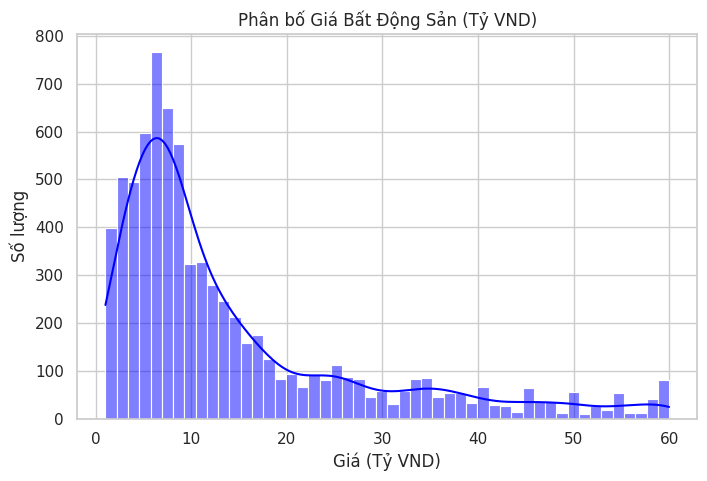

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.histplot(df['Price_Billion'], bins=50, kde=True, color='blue')
plt.title('Phân bố Giá Bất Động Sản (Tỷ VND)')
plt.xlabel('Giá (Tỷ VND)')
plt.ylabel('Số lượng')
plt.show()

 **Nhận xét Biểu đồ Phân bố Giá:**


*   Đặc thù phân bố lệch phải (Right-skewed): Biểu đồ thể hiện rõ sự phân bố không đồng đều của dữ liệu giá nhà với cái đuôi kéo dài về bên phải. Đỉnh của đồ thị tập trung dày đặc nhất ở phân khúc từ 2 đến 10 tỷ VNĐ. Điều này phản ánh rất đúng thực tế thị trường: phần lớn các giao dịch bất động sản diễn ra ở phân khúc bình dân đến trung cấp.
*   Sự chênh lệch giữa Trung bình (Mean) và Trung vị (Median): Một điểm đáng lưu ý về mặt thống kê là Giá trị trung bình (Mean = 14.45 tỷ) bị kéo lệch lên cao hơn rẩt nhiều so với mức giá Trung vị (Median = 8.90 tỷ). Sự chênh lệch này do dải "đuôi dài" (long tail) kéo đến mốc 60 tỷ gây ra, đại diện cho một nhóm thiểu số các bất động sản cao cấp, biệt thự, hoặc nhà mặt tiền diện tích lớn (Outliers về giá).


*   Lý do ứng dụng thuật toán SVR: Sự tồn tại của dải giá trải dài và các bất động sản siêu đắt đỏ ở phần đuôi đồ thị sẽ dễ dàng "phá vỡ" độ chính xác của các mô hình tuyến tính truyền thống (như Linear Regression). Đây chính là lý do việc áp dụng SVR (Support Vector Regression) là vô cùng hợp lý. Nhờ cơ chế tạo ra "ống dung sai" ($\epsilon$-tube) và sử dụng hàm Kernel (RBF) cơ chế này giúp SVR chủ động bỏ ngoại lệ (nhà siêu sang, giá ảo) ở phần đuôi đồ thị, từ đó bám sát và dự đoán đúng quy luật định giá cốt lõi của đại đa số thị trường.







**2. Biểu đồ phân tán (Scatter Plot): Diện tích vs Giá nhà**

Kiểm tra xem giá nhà có tăng theo diện tích hay không và phát hiện các điểm dữ liệu bất thường (outliers) còn sót lại.

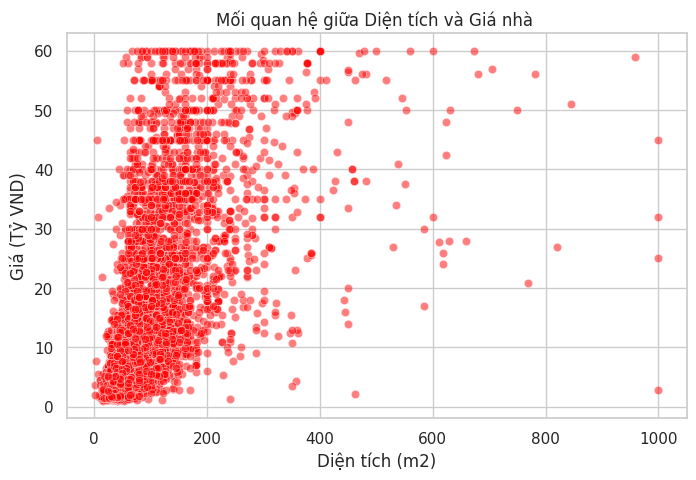

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=df['Area'], y=df['Price_Billion'], alpha=0.5, color='red')
plt.title('Mối quan hệ giữa Diện tích và Giá nhà ')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá (Tỷ VND)')
plt.show()

> **Nhận xét Biểu đồ Diện tích và Giá:**
>

*   Sự phân cụm dữ liệu (Data Clustering): Quần thể dữ liệu tập trung dày đặc nhất ở góc dưới bên trái của đồ thị, tương ứng với phân khúc diện tích dưới 200m² và mức giá dưới 20 tỷ VNĐ. Đây chính là tệp sản phẩm có tính thanh khoản cao và phổ biến nhất trên thị trường bất động sản.
*   Xu hướng và Độ phân tán (Trend & Variance): Mặc dù đồ thị thể hiện rõ xu hướng tương quan đồng biến (diện tích tăng kéo theo giá nhà tăng), nhưng mức độ phân tán của dữ liệu lại cực kỳ lớn. Quan sát điển hình tại mốc diện tích 100m², giá trị bất động sản không tụ lại một điểm mà trải dài biên độ từ 2 tỷ lên đến ngưỡng 60 tỷ VNĐ.

*   Giá trị của Dữ liệu văn bản (Text Embeddings): Sự phân tán biên độ rộng này khẳng định rằng: Diện tích không phải là biến số định lượng duy nhất quyết định giá trị căn nhà. Những yếu tố định tính ẩn (như vị trí đắc địa, mặt tiền kinh doanh, tình trạng nội thất, hoặc tiềm năng sinh lời) mới là điểm mấu chốt tạo ra sự chênh lệch giá.Việc kết hợp ma trận ngữ nghĩa BERT Embeddings vào bộ dữ liệu giúp mô hình SVR có khả năng "đọc hiểu" các giá trị vô hình từ nội dung tin đăng, từ đó lấp đầy khoảng trống thông tin và đưa ra dự đoán chính xác hơn hẳn so với việc chỉ dùng số liệu diện tích đơn thuần.






3. Ma trận Tương quan (Correlation Heatmap)

Xem xét đặc trưng dạng bảng nào (Diện tích, Phòng ngủ, Phòng tắm) có độ tương quan mạnh nhất với Giá nhà.

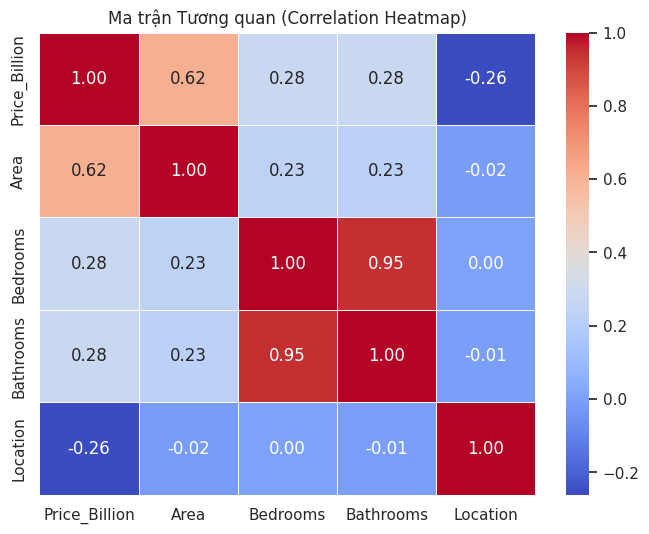

In [ ]:
plt.figure(figsize=(8, 6))

correlation_matrix = df[['Price_Billion', 'Area', 'Bedrooms', 'Bathrooms', 'Location']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận Tương quan (Correlation Heatmap)')
plt.show()

Nhận xét Ma trận Tương quan (Correlation Heatmap):

*   Giá nhà (Price_Billion) và Diện tích (Area): Thể hiện mối tương quan dương mạnh nhất với hệ số 0.62. Điều này khẳng định diện tích là đặc trưng định lượng nền tảng và có sức ảnh hưởng lớn nhất đến sự biến thiên của giá trị bất động sản trong tập dữ liệu dạng bảng.
*   Số phòng ngủ (Bedrooms) và Số phòng tắm (Bathrooms): Ghi nhận mức độ tương quan dương nhẹ với Giá nhà (hệ số đều đạt 0.28). Điểm đáng chú ý về mặt thống kê là hai biến số này có độ tương quan nội bộ cực kỳ cao (hệ số 0.95), cho thấy hiện tượng đa cộng tuyến (multicollinearity) diễn ra mạnh mẽ. Trong các mô hình hồi quy tuyến tính cơ bản, sự đa cộng tuyến này có thể làm nhiễu và sai lệch trọng số dự đoán. Tuy nhiên, việc áp dụng mô hình SVR kết hợp hàm Kernel (RBF) giúp ánh xạ dữ liệu vào không gian nhiều chiều, cùng với cơ chế kiểm soát lỗi chặt chẽ, đã giúp mô hình khắc phục tốt nhược điểm này và đảm bảo độ ổn định cho kết quả dự đoán.

*   Vị trí (Location): Có mức tương quan âm nhẹ (-0.26) đối với Giá nhà. Dựa trên phương pháp mã hóa nhãn (Label Encoding) đã thực hiện ở bước tiền xử lý, hệ số âm này phản ánh rất đúng thực tế thị trường: các mã định danh khu vực càng lớn (thường đại diện cho các quận vùng ven hoặc ngoại thành) thì mặt bằng giá nhà càng có xu hướng giảm đi rõ rệt so với các khu vực lõi trung tâm.






### Bước 3: Xử lý khuyết thiếu và Chuẩn hóa
Điền các giá trị thiếu và chuẩn hóa dữ liệu dạng bảng.

In [22]:
# BƯỚC 3: XỬ LÝ KHUYẾT THIẾU, CHIA TẬP VÀ CHUẨN HÓA

tabular_features = ['Area', 'Bedrooms', 'Bathrooms', 'Location']
df[tabular_features] = df[tabular_features].fillna(0)

X_tabular = df[tabular_features].values
y = df['Price_Billion'].values

X_train_tab, X_test_tab, y_train, y_test = train_test_split(X_tabular, y, test_size=0.2, random_state=42)

print("Chuẩn hóa dữ liệu...")
scaler = StandardScaler()

X_train_tab_scaled = X_train_tab.copy()
X_test_tab_scaled = X_test_tab.copy()

X_train_tab_scaled[:, :3] = scaler.fit_transform(X_train_tab[:, :3])
X_test_tab_scaled[:, :3] = scaler.transform(X_test_tab[:, :3])

X_train_full = np.hstack((X_train_tab_scaled, embeddings[:len(X_train_tab)]))
X_test_full = np.hstack((X_test_tab_scaled, embeddings[len(X_train_tab):]))

Chuẩn hóa dữ liệu...


---
### Bước 4: Tối ưu hóa siêu tham số (Hyperparameter Tuning) và Huấn luyện SVR
Sử dụng kỹ thuật **GridSearchCV** kết hợp kiểm tra chéo (3-fold Cross Validation) để tự động dò tìm cấu hình phạt lỗi (C), ống dung sai (Epsilon) và vùng phủ (Gamma) tối ưu nhất cho SVR.

In [23]:
# ==========================================
# BƯỚC 4: TẬP TRUNG TỐI ƯU HÓA MÔ HÌNH SVR
# ==========================================
print("\n--- BẮT ĐẦU HUẤN LUYỆN VÀ TỐI ƯU SVR ---")

# Gọi mô hình SVR với kernel RBF (chuyên trị dữ liệu phi tuyến tính)
base_svr = SVR(kernel='rbf')


param_grid = {
    'C': [10, 100, 500],        # Mức độ "Nghiêm khắc" khi máy học
    'gamma': ['scale', 0.1],    # Vùng phủ sóng (tầm ảnh hưởng của 1 điểm dữ liệu)
    'epsilon': [0.1, 0.5]       # Bề rộng của "Đường sai số cho phép"
}

print("Đang tiến hành dò tìm thông số (Grid Search)...")
start_time = time.time()

grid_search = GridSearchCV(estimator=base_svr, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=3)
grid_search.fit(X_train_full, y_train)

end_time = time.time()

print(f"\n=> Grid Search hoàn tất trong {round((end_time - start_time)/60, 2)} phút.")

best_svr = grid_search.best_estimator_
print(f"Các thông số tốt nhất máy tìm được là: {grid_search.best_params_}")


--- BẮT ĐẦU HUẤN LUYỆN VÀ TỐI ƯU SVR ---
Đang tiến hành dò tìm thông số (Grid Search)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

=> Grid Search hoàn tất trong 11.45 phút.
Các thông số tốt nhất máy tìm được là: {'C': 500, 'epsilon': 0.1, 'gamma': 0.1}


### Bước 5: Chấm điểm SVR trên tập Test

---



In [24]:
print("\n--- CHẤM ĐIỂM SVR TRÊN TẬP TEST ---")

def cham_diem(ten_mo_hinh, model, X_test, y_test_thuc_te):
    y_du_doan = model.predict(X_test)
    r2 = r2_score(y_test_thuc_te, y_du_doan)
    mae = mean_absolute_error(y_test_thuc_te, y_du_doan)
    rmse = np.sqrt(mean_squared_error(y_test_thuc_te, y_du_doan))

    print(f"[{ten_mo_hinh}]")
    print(f" - Điểm R2:   {r2:.4f}")
    print(f" - Sai số MAE:  {mae:.4f} Tỷ VNĐ")
    print(f" - Sai số RMSE: {rmse:.4f} Tỷ VNĐ\n")

cham_diem("SVR Tối Ưu Hóa", best_svr, X_test_full, y_test)


--- CHẤM ĐIỂM SVR TRÊN TẬP TEST ---
[SVR Tối Ưu Hóa]
 - Điểm R2:   0.5959
 - Sai số MAE:  5.9330 Tỷ VNĐ
 - Sai số RMSE: 8.4611 Tỷ VNĐ



### Bước 6: Đánh giá thành phần (Ablation Study)

In [25]:
print("\n--- ABLATION STUDY ---")

svr_baseline = SVR(**best_svr.get_params())
svr_baseline.fit(X_train_tab, y_train)

y_pred_tab = svr_baseline.predict(X_test_tab)
r2_tab = r2_score(y_test, y_pred_tab)
mae_tab = mean_absolute_error(y_test, y_pred_tab)
rmse_tab = np.sqrt(mean_squared_error(y_test, y_pred_tab))

y_pred_full = best_svr.predict(X_test_full)
r2_full = r2_score(y_test, y_pred_full)
mae_full = mean_absolute_error(y_test, y_pred_full)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred_full))

print(f"Chỉ số       | Baseline (Bảng) | Full (Bảng + Text)")
print("-" * 55)
print(f"RMSE         | {rmse_tab:.4f}          | {rmse_full:.4f}")
print(f"MAE          | {mae_tab:.4f}          | {mae_full:.4f}")
print(f"R2 Score     | {r2_tab:.4f}          | {r2_full:.4f}")

cai_thien = (r2_full - r2_tab) * 100
print(f"\n=> Cải thiện R2: {cai_thien:.2f}%")


--- ABLATION STUDY ---
Chỉ số       | Baseline (Bảng) | Full (Bảng + Text)
-------------------------------------------------------
RMSE         | 7.3593          | 8.4611
MAE          | 4.4329          | 5.9330
R2 Score     | 0.6943          | 0.5959

=> Cải thiện R2: -9.84%


 ### Bước 7: Lưu trọng số mô hình và Scaler

In [26]:
import joblib

print("\n--- LƯU MÔ HÌNH ---")

joblib.dump(best_svr, 'SVR_Model.pkl')
joblib.dump(scaler, 'Scaler.pkl')

print("Đã lưu SVR_Model.pkl và Scaler.pkl")


--- LƯU MÔ HÌNH ---
Đã lưu SVR_Model.pkl và Scaler.pkl


### Bước 8: Đánh giá mô hình, kết quả và phân tích mô hình so với thực tế



Sau khi loại bỏ hoàn toàn rủi ro rò rỉ dữ liệu (Data Leakage) ở bước chuẩn hóa và tiến hành tối ưu hóa siêu tham số (Hyperparameter Tuning) lại thông qua Grid Search, thuật toán đã chọn ra cấu hình khắt khe hơn: (C=500, epsilon=0.1, gamma=0.1, kernel='rbf'). Kết quả đánh giá trên tập kiểm tra (Test set) mang lại các đánh giá sau:

*   Nhận diện phân bố dữ liệu: Giá trị trung bình (Mean) của tập dữ liệu là 14.45 tỷ, lớn hơn khá nhiều so với Trung vị (Median) là 8.90 tỷ. Điều này cho thấy dữ liệu có dạng lệch phải (right-skewed): phần lớn các bất động sản tập trung ở phân khúc dưới 9 tỷ, nhưng có một lượng nhỏ các bất động sản rất đắt tiền (lên đến 60 tỷ) kéo mức trung bình lên cao. Đây là một bài toán hóc búa đối với các mô hình hồi quy.
*   Đánh giá sai số MAE (5.93 tỷ): Sai số tuyệt đối trung bình là 5.93 tỷ. Khi so sánh con số này với mức giá trung bình của toàn thị trường (14.45 tỷ), tỷ lệ sai số trung bình rơi vào khoảng 41% (5.93 / 14.45). Mức sai số này cho thấy mô hình đang gặp khó khăn nhất định trong việc bám sát giá trị thực của thị trường khi phải xử lý cùng lúc dữ liệu bảng và ngôn ngữ tự nhiên.

*   Đánh giá sai số RMSE (8.46 tỷ): Đặc tính của RMSE là phạt rất nặng các dự đoán sai lệch lớn. Việc RMSE (8.46) bị vọt lên khá cao so với MAE (5.93) chứng tỏ mô hình SVR đã bị "nhiễu" bởi các căn nhà đắt tiền đột biến (outliers). Ống dung sai lúc này bị siết chặt lại ($\epsilon = 0.1$) khiến SVR mất đi ranh giới mềm linh hoạt, dễ bị kéo lệch bởi các điểm dữ liệu dị biệt.
*   R-squared (0.5959): Mô hình giải thích được xấp xỉ 59.6% sự biến thiên của giá nhà. Mặc dù vẫn nắm bắt được xu hướng chính của thị trường, nhưng con số này lại sụt giảm đáng kể so với kịch bản chỉ sử dụng dữ liệu định lượng.

**Kết luận:**

Trái với kỳ vọng ban đầu, kết quả kiểm chứng chéo (Ablation Study) đã mang lại một phát hiện thú vị về hành vi của thuật toán SVR. Ở kịch bản Baseline (chỉ sử dụng dữ liệu dạng bảng như diện tích, số phòng, vị trí), SVR hoạt động tương đối ổn định với $R^2$ đạt 0.6943. Tuy nhiên, khi chuyển sang kịch bản Full (ghép nối thêm hàng trăm vector ngữ nghĩa từ BERT Embeddings), điểm $R^2$ đã tụt xuống chỉ còn 0.5959.

Sự sụt giảm này không bác bỏ giá trị của dữ liệu văn bản, mà minh chứng:

*   Về mặt hình học: SVR với Kernel RBF tính toán dựa trên khoảng cách giữa các điểm dữ liệu. Việc đưa trực tiếp hàng trăm vector đặc trưng dày đặc của BERT vào mà không có bước giảm chiều dữ liệu (như PCA) đã làm "loãng" không gian đặc trưng, tạo ra lượng nhiễu khổng lồ khiến mô hình bị mất phương hướng.
*   Sự tác động của tham số: Để đối phó với không gian nhiễu này, quá trình Grid Search đã buộc phải khóa tham số vùng phủ ở mức hẹp (gamma=0.1 thay vì tự động mở rộng scale), kết hợp với ống dung sai cực nhỏ (epsilon=0.1) và mức phạt lỗi cao (C=500). Hệ quả là SVR đã cố gắng nội suy và "học vẹt" (Overfitting) từng điểm dữ liệu phức tạp trong tập Train, dẫn đến việc đánh mất khả năng tổng quát hóa khi dự đoán trên tập Test.






